# AdversarialQA Dataset Exploration

Adversarially collected QA dataset (~30K examples).  
Human annotators tried to fool models — great for robustness.  
HuggingFace: `adversarial_qa`  
Subsets: `adversarialQA` (combined), `dbert`, `dbidaf`, `droberta`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

Tokenizer vocab size: 30522


In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

ADVERSARIALQA_HF_ID = 'adversarial_qa'
ADVERSARIALQA_SUBSET = 'adversarialQA'  # combined; alternatives: 'dbert', 'dbidaf', 'droberta'
print(f'DATA_PATH: {DATA_PATH}')
print(f'ADVERSARIALQA_HF_ID: {ADVERSARIALQA_HF_ID} ({ADVERSARIALQA_SUBSET})')

DATA_PATH: Q:\data
ADVERSARIALQA_HF_ID: adversarial_qa (adversarialQA)


## Load AdversarialQA

In [ ]:
# Load AdversarialQA from HuggingFace
ds_aqa = load_dataset(ADVERSARIALQA_HF_ID, ADVERSARIALQA_SUBSET, cache_dir=str(DATA_PATH))
print(f'Splits: {list(ds_aqa.keys())}')
for split_name, split_ds in ds_aqa.items():
    print(f'  {split_name}: {len(split_ds)} examples')
print(f'\nFeatures: {list(ds_aqa["train"].features.keys())}')

Generating train split:   0%|          | 0/30000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Splits: ['train', 'validation', 'test']
  train: 30000 examples
  validation: 3000 examples
  test: 3000 examples

Features: ['id', 'title', 'context', 'question', 'answers', 'metadata']


In [5]:
# Examine the structure of one example
ex = ds_aqa['train'][0]
print('Keys:', list(ex.keys()))
print()
for k, v in ex.items():
    if isinstance(v, str):
        print(f'{k}: {v[:200]}{"..." if len(v) > 200 else ""}')
    elif isinstance(v, dict):
        print(f'{k}: {v}')
    elif isinstance(v, list):
        print(f'{k}: {v[:5]}{"..." if len(v) > 5 else ""}')
    else:
        print(f'{k}: {v}')

Keys: ['id', 'title', 'context', 'question', 'answers', 'metadata']

id: 7ba1e8f4261d3170fcf42e84a81dd749116fae95
title: Brain
context: Another approach to brain function is to examine the consequences of damage to specific brain areas. Even though it is protected by the skull and meninges, surrounded by cerebrospinal fluid, and isola...
question: What sare the benifts of the blood brain barrir?
answers: {'text': ['isolated from the bloodstream'], 'answer_start': [195]}
metadata: {'split': 'train', 'model_in_the_loop': 'Combined'}


## Dataset Statistics

In [6]:
# Convert to DataFrame for easier analysis
ds_train = ds_aqa['train']
df_aqa = ds_train.to_pandas()
n_total = len(df_aqa)
print(f'Train DataFrame: {df_aqa.shape}')
print(f'Columns: {list(df_aqa.columns)}')
print()

# Answer counts
df_aqa['ans_count'] = df_aqa['answers'].apply(lambda a: len(a['text']))
n_empty_ans = (df_aqa['ans_count'] == 0).sum()
print(f'Rows with empty answers: {n_empty_ans}/{n_total}')
print(f'Answers per question: mean={df_aqa["ans_count"].mean():.2f}, max={df_aqa["ans_count"].max()}')
print(df_aqa['ans_count'].value_counts().sort_index())
print()

# Unique contexts
n_unique_ctx = df_aqa['context'].nunique()
n_unique_q = df_aqa['question'].nunique()
print(f'Total rows: {n_total}')
print(f'Unique contexts: {n_unique_ctx}')
print(f'Unique questions: {n_unique_q}')
print(f'Questions per context: ~{n_total / max(n_unique_ctx, 1):.1f}')

Train DataFrame: (30000, 6)
Columns: ['id', 'title', 'context', 'question', 'answers', 'metadata']

Rows with empty answers: 0/30000
Answers per question: mean=1.00, max=1
ans_count
1    30000
Name: count, dtype: int64

Total rows: 30000
Unique contexts: 2648
Unique questions: 29352
Questions per context: ~11.3


Answer char lengths:
count    30000.000000
mean        25.540000
std         37.250814
min          1.000000
25%          7.000000
50%         13.000000
75%         27.000000
max       1654.000000
Name: answers, dtype: float64

Questions per context distribution:
count    2648.000000
mean       11.329305
std         2.949701
min         3.000000
25%         9.000000
50%        11.000000
75%        13.000000
max        27.000000
dtype: float64


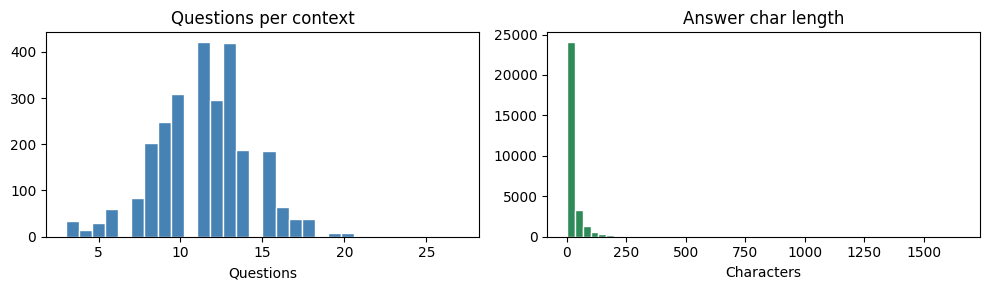

In [7]:
# Answer char length distribution
ans_char_lens = df_aqa['answers'].apply(lambda a: len(a['text'][0]) if len(a['text']) > 0 else 0)
print('Answer char lengths:')
print(ans_char_lens.describe())

# Questions per unique context — distribution
ctx_q_counts = df_aqa.groupby('context').size()
print(f'\nQuestions per context distribution:')
print(ctx_q_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(ctx_q_counts.values, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Questions per context')
axes[0].set_xlabel('Questions')

axes[1].hist(ans_char_lens.values, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Answer char length')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

## Inspect Examples

In [8]:
# Display a few examples
for i in range(5):
    row = df_aqa.iloc[i]
    context = row['context']
    question = row['question']
    answers = row['answers']

    print(f'=== Example {i} ===')
    print(f'  Question: {question}')
    print(f'  Answers:  {answers["text"]}')
    print(f'  Context:  {context[:300].replace(chr(10), " ")}...')

    # Show answer span in context
    if len(answers['text']) > 0:
        ans_text = answers['text'][0]
        ans_start = answers['answer_start'][0]
        ans_end = ans_start + len(ans_text)
        ctx_off = 40
        beg = max(ans_start - ctx_off, 0)
        ctx_around = context[beg:ans_end + ctx_off]
        print(f'  Span [{ans_start}:{ans_end}]: "{ans_text}"')
        print(f'  In context: "...{ctx_around}..."')
    print()

=== Example 0 ===
  Question: What sare the benifts of the blood brain barrir?
  Answers:  ['isolated from the bloodstream']
  Context:  Another approach to brain function is to examine the consequences of damage to specific brain areas. Even though it is protected by the skull and meninges, surrounded by cerebrospinal fluid, and isolated from the bloodstream by the blood–brain barrier, the delicate nature of the brain makes it vulne...
  Span [195:224]: "isolated from the bloodstream"
  In context: "... surrounded by cerebrospinal fluid, and isolated from the bloodstream by the blood–brain barrier, the delicat..."

=== Example 1 ===
  Question: What is surrounded by cerebrospinal fluid?
  Answers:  ['brain']
  Context:  Another approach to brain function is to examine the consequences of damage to specific brain areas. Even though it is protected by the skull and meninges, surrounded by cerebrospinal fluid, and isolated from the bloodstream by the blood–brain barrier, the delicate nat

## Context / Answer Length Distributions

In [9]:
# Tokenize contexts, questions, answers and measure lengths
aqa_ctx_lens = []
aqa_q_lens = []
aqa_ans_lens = []

for _, row in df_aqa.iterrows():
    ctx_toks = tkz(row['context'], add_special_tokens=False).input_ids
    q_toks = tkz(row['question'], add_special_tokens=False).input_ids
    aqa_ctx_lens.append(len(ctx_toks))
    aqa_q_lens.append(len(q_toks))
    for ans in row['answers']['text']:
        ans_toks = tkz(ans, add_special_tokens=False).input_ids
        aqa_ans_lens.append(len(ans_toks))

aqa_ctx_lens = np.array(aqa_ctx_lens)
aqa_q_lens = np.array(aqa_q_lens)
aqa_ans_lens = np.array(aqa_ans_lens)

print(f'Processed {len(aqa_ctx_lens)} examples')
print('\nContext token lengths:')
print(f'  mean={aqa_ctx_lens.mean():.1f}, median={np.median(aqa_ctx_lens):.1f}, '
      f'min={aqa_ctx_lens.min()}, max={aqa_ctx_lens.max()}, std={aqa_ctx_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={aqa_q_lens.mean():.1f}, median={np.median(aqa_q_lens):.1f}, '
      f'min={aqa_q_lens.min()}, max={aqa_q_lens.max()}, std={aqa_q_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={aqa_ans_lens.mean():.1f}, median={np.median(aqa_ans_lens):.1f}, '
      f'min={aqa_ans_lens.min()}, max={aqa_ans_lens.max()}, std={aqa_ans_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (518 > 512). Running this sequence through the model will result in indexing errors


Processed 30000 examples

Context token lengths:
  mean=152.5, median=141.0, min=27, max=693, std=66.9
Question token lengths:
  mean=11.7, median=11.0, min=1, max=59, std=5.2
Answer token lengths:
  mean=5.0, median=3.0, min=1, max=348, std=7.6


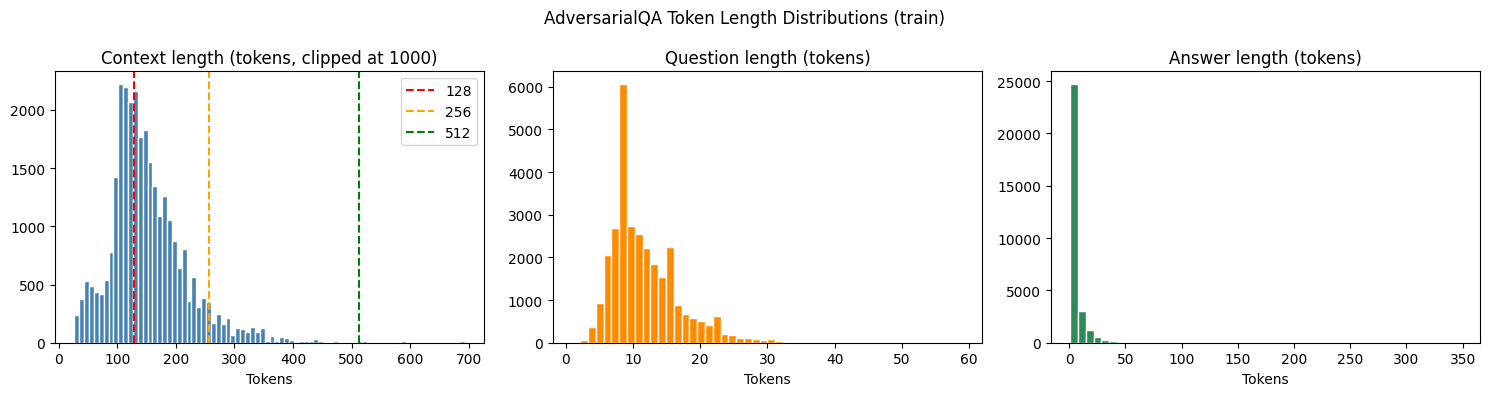

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ctx_clip = np.clip(aqa_ctx_lens, 0, 1000)
axes[0].hist(ctx_clip, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens, clipped at 1000)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(aqa_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(aqa_ans_lens, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens)')
axes[2].set_xlabel('Tokens')

plt.suptitle('AdversarialQA Token Length Distributions (train)')
plt.tight_layout()
plt.show()

In [11]:
# Chunk analysis
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2  # CLS + SEP
    n_chunks = np.ceil(aqa_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(aqa_ctx_lens)} ({multi/len(aqa_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 18275/30000 (60.9%), max chunks: 6, mean chunks: 1.70
inp_len=256: need >1 chunk: 2155/30000 (7.2%), max chunks: 3, mean chunks: 1.07
inp_len=384: need >1 chunk: 245/30000 (0.8%), max chunks: 2, mean chunks: 1.01
inp_len=512: need >1 chunk: 50/30000 (0.2%), max chunks: 2, mean chunks: 1.00


## Convert to Unified QnA Format

In [ ]:
# Convert AdversarialQA to unified QnA format: (context, question, answer, source)
# Use first answer from each example across all splits
rows_unified = []
for split_name in ds_aqa.keys():
    ds_split = ds_aqa[split_name]
    for i in range(len(ds_split)):
        ex = ds_split[i]
        context = ex['context']
        question = ex['question']
        answers = ex['answers']['text']
        if not answers or not context.strip() or not question.strip():
            continue
        rows_unified.append({
            'context': context,
            'question': question,
            'answer': answers[0],
            'source': 'adversarialqa',
        })

df_unified_aqa = pd.DataFrame(rows_unified)
print(f'Unified AdversarialQA rows (all splits): {len(df_unified_aqa)}')
df_unified_aqa.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'adversarialqa_unified.parquet'
df_unified_aqa.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_aqa)} rows)')